# Stanza Lemmatizer + Krahasim me/pa Lemmatizim 

Ky notebook:
1. Instalon dhe konfiguron **Stanza** (lemmatizues per anglishten)
2. Aplikon lemmatizimin mbi te dhenat — **ne batch, me checkpoint-e**, jo rresht-pas-rreshti
3. Ritrajnon te 5 modelet me tekst te lemmatizuar (TF-IDF e reduktuar per RAM/shpejtesi)
4. Krahason metrikat **me** dhe **pa** lemmatizim

> **Kushti:** `mlp_model.ipynb` duhet te kete ekzekutuar se pari  
> (kerkohet `../data/results_no_lemmatization.csv`)

**Optimizimet kryesore te shtuara:**
- Lemmatizimi Stanza ekzekutohet ne **batch** permes `stanza.Document` te shumefishte ne nje thirrje te vetme te pipeline-it (`nlp(documents_list)`), qe shfrytezon batch-ing-un e brendshem te rrjetit neural te Stanza-s ne vend te nje thirrje per cdo rresht (overhead i madh per thirrje te vogla).
- **Checkpoint-e te shpeshta** (cdo N rreshta) ne disk, jo vetem ne fund — nese procesi nderpritet, nuk humbet gjithe puna.
- TF-IDF e re (`vectorizer_lem`) perdor `max_features`, `min_df`, `sublinear_tf` dhe `dtype=float32` per te reduktuar fjalorin dhe RAM-in — KJO NUK prek vectorizer-in origjinal te `eda.ipynb` (ai mbetet i ndryshuar nga zero).
- MLP ne kete notebook tani perdor **te njejten arkitekture** si `mlp_model.ipynb`
- `gc.collect()` dhe fshirje e ndryshoreve te perkohshme pas hapave me konsum te larte memorie.

## 1. Instalimi i Stanza

In [7]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'stanza', 'tqdm', '-q'])
print('Stanza u instalua.')

Stanza u instalua.


## 2. Shkarko modelin anglisht te Stanza

Shkarkohet vetem here te pare (~500MB). Pas kesaj ruhet lokalisht.

In [9]:
import stanza

# Shkarkohet modeli anglisht
stanza.download('en', processors='tokenize,lemma', verbose=False)

# Inicializimi pipeline-it
# tokenize: ndane tekstin ne fjale
# lemma: kthen cdo fjale ne formen baze (runs->run, better->good)

nlp = stanza.Pipeline(
    lang='en',
    processors='tokenize,lemma',
    use_gpu=False,
    tokenize_batch_size=64,
    lemma_batch_size=128,
    verbose=False
)

print('Stanza Pipeline gati.')

Stanza Pipeline gati.


## 3. Funksioni i lemmatizimit (batch)

### Cfare ben lemmatizimi?

| Fjala origjinale | Pas lemmatizimit |
|---|---|
| `running` | `run` |
| `better` | `good` |
| `was` | `be` |
| `claimed` | `claim` |
| `politicians` | `politician` |

Kjo redukton fjalorin dhe ndihmon modelet te gjejne relacione midis formave te ndryshme te se njejtes fjale.

**Ne vend te nje thirrje `nlp(text)` per cdo rresht (e ngadalshme per shkak te overhead-it te brendshem te pipeline-it per cdo thirrje), Stanza pranon nje **liste dokumentesh** (`stanza.Document`) ne nje thirrje te vetme dhe i proceson ne batch — kjo redukton ndjeshem kohen totale, sidomos per dataseta te medha (~57k rreshta).

In [10]:
def lemmatize_batch(texts, max_chars=5000):
    """Lemmatizon nje liste tekstesh ne nje thirrje te vetme batch te Stanza.

    Krahasuar me thirrjen rresht-pas-rreshti, kjo shfrytezon batch-ing-un e
    brendshem te rrjetit neural te Stanza-s dhe redukton overhead-in per
    thirrje (inicializim tensor-esh, etj.) per cdo dokument individual.
    """
    cleaned = [str(t)[:max_chars] if isinstance(t, str) and len(t.strip()) > 0 else '' for t in texts]
    # stanza.Document(text) per cdo element — i kalojme te gjithe ne nje thirrje pipeline
    docs_in = [stanza.Document([], text=t) if t else stanza.Document([], text=' ') for t in cleaned]
    try:
        docs_out = nlp(docs_in)
    except Exception:
        # fallback: nese batch-i deshton (rast i rralle), kthe tekstet origjinale per kete batch
        return cleaned
    results = []
    for orig, doc in zip(cleaned, docs_out):
        if not orig:
            results.append(orig)
            continue
        lemmas = [word.lemma if word.lemma else word.text
                  for sent in doc.sentences for word in sent.words]
        results.append(' '.join(lemmas))
    return results

# Test me shembull
sample = ['The politicians were claiming that scientists had confirmed the findings.']
print('Origjinal: ', sample[0])
print('Lemmatizuar:', lemmatize_batch(sample)[0])

Origjinal:  The politicians were claiming that scientists had confirmed the findings.
Lemmatizuar: the politician be claim that scientist have confirm the finding .


## 4. Ngarko te dhenat dhe apliko lemmatizimin

> Lemmatizimi i te gjitha te dhenave proceset ne **batch-e te medha** (nuk eshte me rresht-pas-rreshti), me **checkpoint** cdo `CHECKPOINT_EVERY` rreshta ne nje skedar te perkohshem — nese procesi nderpritet (p.sh. mungese RAM, mbylllje e papritur), rifillon nga checkpoint-i i fundit ne vend qe te ribej gjithe punen.

In [11]:
import pandas as pd
import numpy as np
import os
import time
import gc
from tqdm import tqdm

# Ngarko te dhenat e pastruara
df = pd.read_csv('../data/processed/welfake_clean.csv')
df = df.dropna(subset=['content', 'label'])
print(f'Te dhena: {len(df):,} artikuj')

Te dhena: 72,095 artikuj


In [12]:
LEMMA_PATH = '../data/processed/welfake_lemmatized.csv'
CHECKPOINT_PATH = '../data/processed/welfake_lemmatized_partial.csv'
BATCH_SIZE = 64           # numri i dokumenteve te dhena Stanza-s ne nje thirrje
CHECKPOINT_EVERY = 2000   # ruaj progresin ne disk cdo N rreshta te perfunduar

if os.path.exists(LEMMA_PATH):
    print('Skedari lemmatizuar ekziston — po ngarkohet...')
    df_lemma = pd.read_csv(LEMMA_PATH)
    print(f'Ngarkuar: {len(df_lemma):,} artikuj')
else:
    contents = df['content'].tolist()
    total = len(contents)

    # Rifillo nga checkpoint nese ekziston (mbron kunder nderprerjeve)
    start_idx = 0
    lemmatized = []
    if os.path.exists(CHECKPOINT_PATH):
        ck = pd.read_csv(CHECKPOINT_PATH)
        lemmatized = ck['content_lemma'].tolist()
        start_idx = len(lemmatized)
        print(f'Checkpoint i gjetur — duke rifilluar nga rreshti {start_idx:,}/{total:,}')

    print('Duke aplikuar Stanza lemmatizimin (batch)...')
    t0 = time.time()

    for batch_start in tqdm(range(start_idx, total, BATCH_SIZE), desc='Lemmatizim'):
        batch_texts = contents[batch_start: batch_start + BATCH_SIZE]
        lemmatized.extend(lemmatize_batch(batch_texts))

        done = len(lemmatized)
        if done % CHECKPOINT_EVERY < BATCH_SIZE:
            pd.DataFrame({'content_lemma': lemmatized}).to_csv(CHECKPOINT_PATH, index=False)

    elapsed = time.time() - t0
    print(f'Lemmatizimi perfundoi ne {elapsed/60:.1f} minuta.')

    df_lemma = df.copy()
    df_lemma['content'] = lemmatized[:len(df_lemma)]
    df_lemma.to_csv(LEMMA_PATH, index=False)

    # Pastrim: checkpoint-i i perkohshem nuk nevojitet me
    if os.path.exists(CHECKPOINT_PATH):
        os.remove(CHECKPOINT_PATH)

    print(f'U ruajt: {LEMMA_PATH}')

gc.collect()

Duke aplikuar Stanza lemmatizimin (batch)...


Lemmatizim: 100%|██████████| 1127/1127 [2:03:52<00:00,  6.59s/it]   


Lemmatizimi perfundoi ne 123.9 minuta.
U ruajt: ../data/processed/welfake_lemmatized.csv


95446

## 5. Shembulli para/pas lemmatizimit

In [13]:
idx = 0
print('=== SHEMBULLI NR.', idx, '===')
print('\nPa lemmatizim:')
print(str(df['content'].iloc[idx])[:400])
print('\nMe lemmatizim (Stanza):')
print(str(df_lemma['content'].iloc[idx])[:400])

=== SHEMBULLI NR. 0 ===

Pa lemmatizim:
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and

Me lemmatizim (Stanza):
law enforcement on high alert follow threats against cops and white on 9 - 11 by # blacklivesmatter and #fyf911 terrorist [ video ] no comment be expect from Barack Obama Member of the #fyf911 or # fukyoflag and # blacklivesmatter movement call for the lynching and hang of white person and cop . they encourage other on a radio show Tuesday night to turn the tide and kill white person and cop to se


## 6. Ndarja train/test + TF-IDF me tekst lemmatizuar (e optimizuar)

**Ndryshim nga origjinali:** ky `TfidfVectorizer` eshte i pavarur nga ai i `eda.ipynb` (i quajtur `vectorizer_lem`, ruajtur ne skedar te vecante `tfidf_vectorizer_lemmatized.pkl`), keshtu qe shtimi i `max_features`/`min_df` **nuk prek** vectorizer-in qe perdorin LR/NB/SVM/RF/MLP ne `eda.ipynb` apo `mlp_model.ipynb`.

| Parametër | Vlera | Arsyeja |
|---|---|---|
| `max_features` | `60000` | Kufizon fjalorin maksimal — redukton RAM dhe kohen e fit per te 5 modelet ne kete notebook |
| `min_df` | `3` | Heq fjalet qe shfaqen ne <3 dokumente — kontribuojne minimalisht ne sinjal dhe shtojne zhurme/overfitting |
| `max_df` | `0.7` | Identike me `eda.ipynb` — heq fjalet shume te zakonshme |
| `sublinear_tf` | `True` | Perdor `1 + log(tf)` ne vend te `tf` te thjeshte — zbut ndikimin e fjaleve te perseritura shume here ne nje dokument |
| `dtype` | `np.float32` | Gjysma e RAM-it per matricen sparse krahasuar me float64 default |
| `stop_words` | `'english'` | Identike me `eda.ipynb` per konsistence |

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib

X_lem = df_lemma['content']
y_lem = df_lemma['label']

# E njejta ndarja: test_size=0.2, random_state=42, stratify
X_train_lem, X_test_lem, y_train_lem, y_test_lem = train_test_split(
    X_lem, y_lem,
    test_size=0.2,
    random_state=42,
    stratify=y_lem
)

# TF-IDF e reduktuar — shih shenimet me siper per cdo parameter
vectorizer_lem = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,
    max_features=60_000,
    min_df=3,
    sublinear_tf=True,
    dtype=np.float32
)

X_train_lem_tfidf = vectorizer_lem.fit_transform(X_train_lem)
X_test_lem_tfidf  = vectorizer_lem.transform(X_test_lem)

joblib.dump(vectorizer_lem, '../models/tfidf_vectorizer_lemmatized.pkl')

print(f'Train: {X_train_lem_tfidf.shape[0]:,} x {X_train_lem_tfidf.shape[1]:,}')
print(f'Test:  {X_test_lem_tfidf.shape[0]:,} x {X_test_lem_tfidf.shape[1]:,}')

# Te dhenat tekstuale te plota nuk nevojiten me ne RAM njekohesisht me matricat
del X_lem
gc.collect()

Train: 57,676 x 60,000
Test:  14,419 x 60,000


0

## 7. Trajnimi i te 5 modeleve me tekst lemmatizuar



In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score
)

# Konfigurimet — MLP tani identik me mlp_model.ipynb (optimizuar) per krahasim te drejte
models_lem = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes':         MultinomialNB(),
    'Linear SVM':          LinearSVC(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'MLP Neural Network':  MLPClassifier(
                               hidden_layer_sizes=(128, 64),
                               activation='relu', solver='adam',
                               alpha=0.0003, batch_size=512,
                               learning_rate='adaptive', learning_rate_init=0.002,
                               max_iter=40, tol=1e-4, early_stopping=True,
                               validation_fraction=0.1,
                               n_iter_no_change=4,
                               random_state=42, verbose=False
                           ),
}

results_lemma = {}

for name, model in models_lem.items():
    print(f'Duke trajnuar {name}...')
    t0 = time.time()
    model.fit(X_train_lem_tfidf, y_train_lem)
    print(f'  Koha e trajnimit: {(time.time()-t0):.1f}s')

    y_pred = model.predict(X_test_lem_tfidf)

    # Score per AUC
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test_lem_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_lem_tfidf)

    results_lemma[name] = {
        'Accuracy':  round(accuracy_score(y_test_lem, y_pred), 4),
        'F1':        round(f1_score(y_test_lem, y_pred, average='weighted'), 4),
        'Precision': round(precision_score(y_test_lem, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_test_lem, y_pred, average='weighted'), 4),
        'AUC':       round(roc_auc_score(y_test_lem, y_score), 4),
    }

    # Ruaj modelin
    fname = name.lower().replace(' ', '_')
    joblib.dump(model, f'../models/{fname}_lemmatized.pkl')
    print(f'  Accuracy: {results_lemma[name]["Accuracy"]:.4f} | AUC: {results_lemma[name]["AUC"]:.4f}')
    gc.collect()

df_results_lemma = pd.DataFrame(results_lemma).T.sort_values('Accuracy', ascending=False)
df_results_lemma.to_csv('../data/results_with_lemmatization.csv')
print('\nRezultatet u ruajten: ../data/results_with_lemmatization.csv')

Duke trajnuar Logistic Regression...
  Koha e trajnimit: 2.2s
  Accuracy: 0.9619 | AUC: 0.9933
Duke trajnuar Naive Bayes...
  Koha e trajnimit: 0.0s
  Accuracy: 0.8774 | AUC: 0.9480
Duke trajnuar Linear SVM...


/Users/beltinaa/fake-news-detection-thesis/venv/lib/python3.9/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


  Koha e trajnimit: 1.3s
  Accuracy: 0.9739 | AUC: 0.9967
Duke trajnuar Random Forest...
  Koha e trajnimit: 47.2s
  Accuracy: 0.9505 | AUC: 0.9913
Duke trajnuar MLP Neural Network...
  Koha e trajnimit: 50.4s
  Accuracy: 0.9678 | AUC: 0.9951

Rezultatet u ruajten: ../data/results_with_lemmatization.csv


## 8. Krahasimi kryesor: pa vs me Lemmatizim

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ngarko rezultatet pa lemmatizim (nga mlp_model.ipynb)
df_no_lemma = pd.read_csv('../data/results_no_lemmatization.csv', index_col=0)
df_with_lemma = df_results_lemma.copy()

# Sigurohu qe rendi i modeleve eshte i njejte
model_order = list(df_no_lemma.index)
df_with_lemma = df_with_lemma.reindex(model_order)

print('=== PA LEMMATIZIM ===')
print(df_no_lemma.to_string())
print()
print('=== ME LEMMATIZIM (Stanza) ===')
print(df_with_lemma.to_string())

=== PA LEMMATIZIM ===
                     Accuracy      F1  Precision  Recall     AUC
Linear SVM             0.9634  0.9634     0.9635  0.9634  0.9936
MLP Neural Network     0.9574  0.9574     0.9574  0.9574  0.9909
Logistic Regression    0.9490  0.9489     0.9491  0.9490  0.9877
Random Forest          0.9408  0.9407     0.9410  0.9408  0.9889
Naive Bayes            0.8681  0.8681     0.8681  0.8681  0.9400

=== ME LEMMATIZIM (Stanza) ===
                     Accuracy      F1  Precision  Recall     AUC
Linear SVM             0.9739  0.9738     0.9739  0.9739  0.9967
MLP Neural Network     0.9678  0.9678     0.9678  0.9678  0.9951
Logistic Regression    0.9619  0.9619     0.9619  0.9619  0.9933
Random Forest          0.9505  0.9505     0.9505  0.9505  0.9913
Naive Bayes            0.8774  0.8774     0.8774  0.8774  0.9480


## 9. Tabela e ndryshimit (Delta)

In [17]:
delta = (df_with_lemma - df_no_lemma).round(4)

print('=== NDIKIMI I LEMMATIZIMIT (me - pa) ===')
print('Vlere pozitive = permiresohet | Negative = keqesohet')
print()
print(delta.to_string())

print()
print('--- Permbledhje per Accuracy ---')
for model in model_order:
    d = delta.loc[model, 'Accuracy']
    ikone = '+ permiresohet' if d > 0 else ('= pa ndryshim' if d == 0 else '- keqesohet')
    print(f'  {model:22s}: {d:+.4f}  ({ikone})')

=== NDIKIMI I LEMMATIZIMIT (me - pa) ===
Vlere pozitive = permiresohet | Negative = keqesohet

                     Accuracy      F1  Precision  Recall     AUC
Linear SVM             0.0105  0.0104     0.0104  0.0105  0.0031
MLP Neural Network     0.0104  0.0104     0.0104  0.0104  0.0042
Logistic Regression    0.0129  0.0130     0.0128  0.0129  0.0056
Random Forest          0.0097  0.0098     0.0095  0.0097  0.0024
Naive Bayes            0.0093  0.0093     0.0093  0.0093  0.0080

--- Permbledhje per Accuracy ---
  Linear SVM            : +0.0105  (+ permiresohet)
  MLP Neural Network    : +0.0104  (+ permiresohet)
  Logistic Regression   : +0.0129  (+ permiresohet)
  Random Forest         : +0.0097  (+ permiresohet)
  Naive Bayes           : +0.0093  (+ permiresohet)


## 10. Grafiku krahasues — Accuracy para/pas lemmatizimit

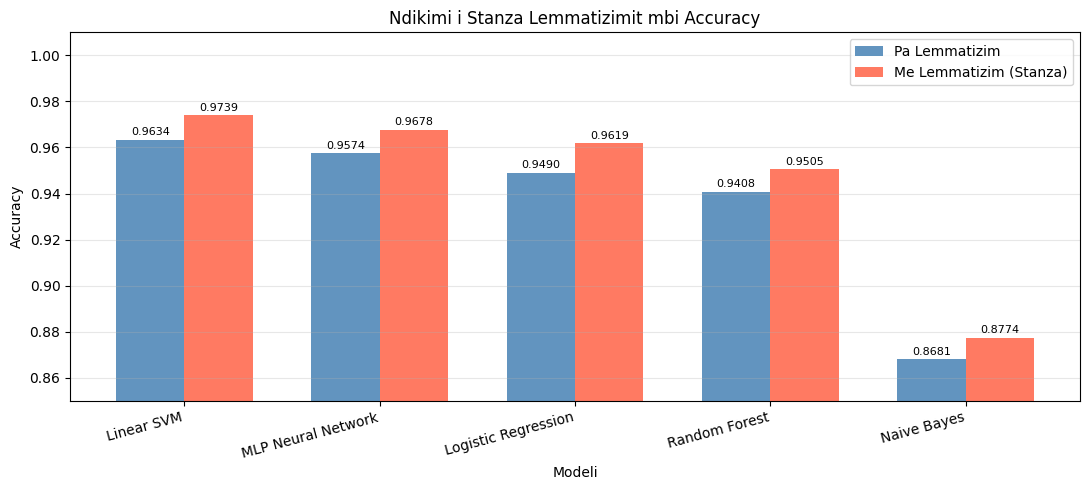

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))

x = np.arange(len(model_order))
w = 0.35

bars1 = ax.bar(x - w/2, df_no_lemma.loc[model_order, 'Accuracy'],
               w, label='Pa Lemmatizim', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, df_with_lemma.loc[model_order, 'Accuracy'],
               w, label='Me Lemmatizim (Stanza)', color='tomato', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Modeli')
ax.set_ylabel('Accuracy')
ax.set_title('Ndikimi i Stanza Lemmatizimit mbi Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(model_order, rotation=15, ha='right')
ax.set_ylim(0.85, 1.01)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/lemmatization_accuracy_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Grafiku per te gjitha metrikat

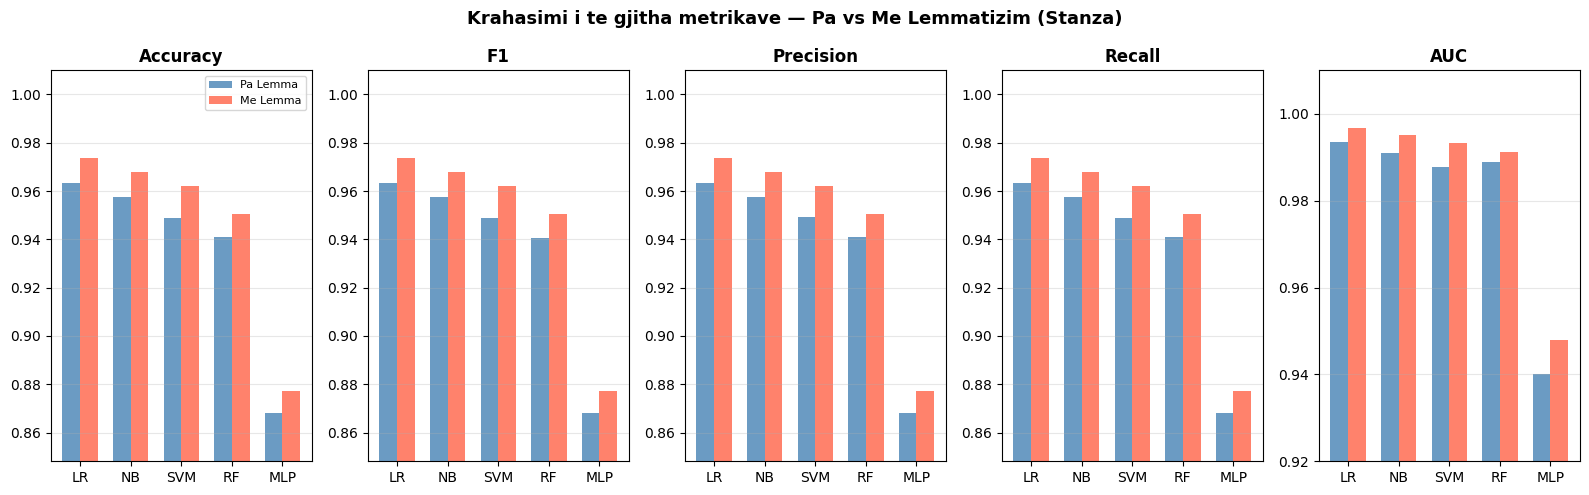

In [19]:
metrics = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5), sharey=False)

for ax, metric in zip(axes, metrics):
    vals_no  = df_no_lemma.loc[model_order, metric].values
    vals_yes = df_with_lemma.loc[model_order, metric].values

    short_names = ['LR', 'NB', 'SVM', 'RF', 'MLP']
    x = np.arange(len(model_order))
    w = 0.35

    ax.bar(x - w/2, vals_no,  w, label='Pa Lemma',  color='steelblue', alpha=0.8)
    ax.bar(x + w/2, vals_yes, w, label='Me Lemma',  color='tomato',    alpha=0.8)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(short_names)
    ax.set_ylim(min(min(vals_no), min(vals_yes)) - 0.02, 1.01)
    ax.grid(axis='y', alpha=0.3)
    if ax == axes[0]:
        ax.legend(fontsize=8)

fig.suptitle('Krahasimi i te gjitha metrikave — Pa vs Me Lemmatizim (Stanza)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/lemmatization_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. ROC Curves — me Lemmatizim

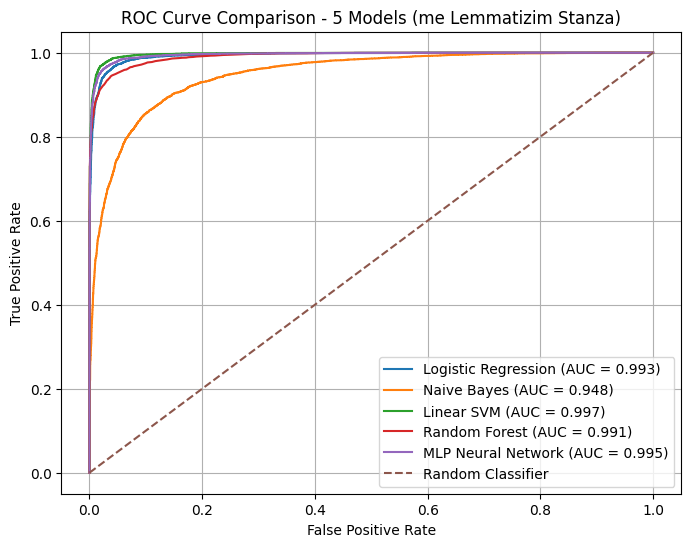

In [20]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, model in models_lem.items():
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test_lem_tfidf)[:, 1]
    else:
        y_score = model.decision_function(X_test_lem_tfidf)
    fpr, tpr, _ = roc_curve(y_test_lem, y_score)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - 5 Models (me Lemmatizim Stanza)')
plt.legend()
plt.grid(True)
plt.savefig('../figures/roc_curves_lemmatized.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Konkluzionet

In [21]:
print('=============================================')
print('       PERMBLEDHJE E REZULTATEVE')
print('=============================================')
print()
print('Ndikimi i Stanza Lemmatizimit (Delta Accuracy):')
print()
for model in model_order:
    d     = delta.loc[model, 'Accuracy']
    no_v  = df_no_lemma.loc[model, 'Accuracy']
    yes_v = df_with_lemma.loc[model, 'Accuracy']
    print(f'  {model:22s}: {no_v:.4f} -> {yes_v:.4f}  (delta: {d:+.4f})')

print()
best_no  = df_no_lemma['Accuracy'].idxmax()
best_yes = df_with_lemma['Accuracy'].idxmax()
print(f'Modeli me i mire pa lemmatizim: {best_no} ({df_no_lemma.loc[best_no, "Accuracy"]:.4f})')
print(f'Modeli me i mire me lemmatizim: {best_yes} ({df_with_lemma.loc[best_yes, "Accuracy"]:.4f})')

avg_delta = delta['Accuracy'].mean()
print()
if avg_delta > 0.001:
    print(f'Konkluzion: Lemmatizimi PERMIRESON mesatarisht me {avg_delta*100:.2f} pike perqindjeje.')
elif avg_delta < -0.001:
    print(f'Konkluzion: Lemmatizimi KEQESON mesatarisht me {abs(avg_delta)*100:.2f} pike perqindjeje.')
else:
    print(f'Konkluzion: Lemmatizimi ka NDIKIM MINIMAL ({avg_delta*100:.3f} pp mesatarisht).')
print()
print('Skedarët e ruajtur:')
print('  ../figures/lemmatization_accuracy_comparison.png')
print('  ../figures/lemmatization_all_metrics.png')
print('  ../figures/roc_curves_lemmatized.png')
print('  ../data/results_with_lemmatization.csv')

       PERMBLEDHJE E REZULTATEVE

Ndikimi i Stanza Lemmatizimit (Delta Accuracy):

  Linear SVM            : 0.9634 -> 0.9739  (delta: +0.0105)
  MLP Neural Network    : 0.9574 -> 0.9678  (delta: +0.0104)
  Logistic Regression   : 0.9490 -> 0.9619  (delta: +0.0129)
  Random Forest         : 0.9408 -> 0.9505  (delta: +0.0097)
  Naive Bayes           : 0.8681 -> 0.8774  (delta: +0.0093)

Modeli me i mire pa lemmatizim: Linear SVM (0.9634)
Modeli me i mire me lemmatizim: Linear SVM (0.9739)

Konkluzion: Lemmatizimi PERMIRESON mesatarisht me 1.06 pike perqindjeje.

Skedarët e ruajtur:
  ../figures/lemmatization_accuracy_comparison.png
  ../figures/lemmatization_all_metrics.png
  ../figures/roc_curves_lemmatized.png
  ../data/results_with_lemmatization.csv
